**Importing All Libraries Which are Req**

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score,accuracy_score,precision_score,recall_score,confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [31]:
df=pd.read_csv("Titanic-Dataset.csv")
df.head()



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [32]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [33]:
df['Age'].fillna(df['Age'].mean(),inplace=True)


/tmp/ipython-input-1275544653.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [34]:
df['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)


/tmp/ipython-input-316750498.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)


In [35]:
df.drop(columns=['Cabin'],inplace=True)

In [36]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [37]:
df.to_csv("Cleaned-Titanic.csv")

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [39]:
le_sex=LabelEncoder()
le_embarked=LabelEncoder()
df['Sex']=le_sex.fit_transform(df['Sex'])
df['Embarked']=le_embarked.fit_transform(df['Embarked'])

In [40]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.000000,1,0,A/5 21171,7.2500,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.000000,1,0,PC 17599,71.2833,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.000000,0,0,STON/O2. 3101282,7.9250,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.000000,1,0,113803,53.1000,2
4,5,0,3,"Allen, Mr. William Henry",1,35.000000,0,0,373450,8.0500,2
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",1,27.000000,0,0,211536,13.0000,2
887,888,1,1,"Graham, Miss. Margaret Edith",0,19.000000,0,0,112053,30.0000,2
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,29.699118,1,2,W./C. 6607,23.4500,2
889,890,1,1,"Behr, Mr. Karl Howell",1,26.000000,0,0,111369,30.0000,0


In [41]:
df[['Pclass','Sex','Age','Fare','Embarked','SibSp','Survived']].corr()


,Pclass,Sex,Age,Fare,Embarked,SibSp,Survived
Pclass,1.000000,0.131900,-0.331339,-0.549500,0.162098,0.083081,-0.338481
Sex,0.131900,1.000000,0.084153,-0.182333,0.108262,-0.114631,-0.543351
Age,-0.331339,0.084153,1.000000,0.091566,-0.026749,-0.232625,-0.069809
Fare,-0.549500,-0.182333,0.091566,1.000000,-0.224719,0.159651,0.257307
Embarked,0.162098,0.108262,-0.026749,-0.224719,1.000000,0.068230,-0.167675
SibSp,0.083081,-0.114631,-0.232625,0.159651,0.068230,1.000000,-0.035322
Survived,-0.338481,-0.543351,-0.069809,0.257307,-0.167675,-0.035322,1.000000


In [42]:
x=df[['Pclass','Sex','Age','Fare','Embarked']]
y=df['Survived']

In [43]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

In [44]:
xtrain.shape

(712, 5)

In [45]:
ytrain.shape

(712,)

In [46]:
model=LinearRegression()
model.fit(xtrain,ytrain)

LinearRegression()

In [47]:
output=model.predict(xtest)
output.shape

(179,)

In [48]:
outb = (output >= 0.5).astype(int)
accuracy = accuracy_score(ytest, outb)
accuracy


0.7877094972067039

In [49]:

accuracy = accuracy_score(ytest,outb)
precision = precision_score(ytest,outb)
recall = recall_score(ytest, outb)
f1 = f1_score(ytest, outb)
conf_matrix = confusion_matrix(ytest, outb)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:\n", conf_matrix)

Accuracy: 0.7877094972067039
Precision: 0.75
Recall: 0.7297297297297297
F1 Score: 0.7397260273972602
Confusion Matrix:
 [[87 18]
 [20 54]]


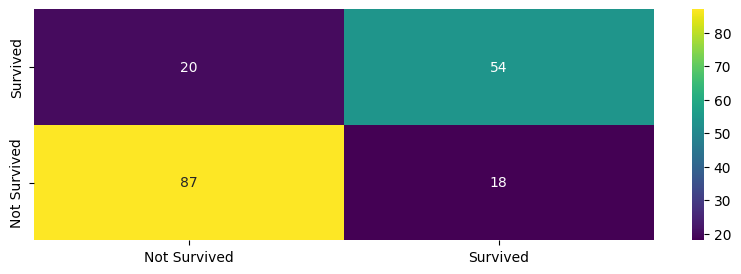

In [50]:
conf_matrix=confusion_matrix(ytest,outb)
labels=['Not Survived','Survived']
fig,axs=plt.subplots(figsize=(10,3))
ax=sns.heatmap(conf_matrix,xticklabels = labels,yticklabels=labels,annot=True,cmap='viridis',fmt='g',ax=axs)
ax.set_ylim([0,len(labels)])
plt.show()

In [63]:
Pclass=int(input("Enter Pclass:"))
Sex=input("Enter Sex:").lower()
Sex=le_sex.transform([Sex])[0]
Age=int(input("Enter Age:"))
Fare=float(input("Enter Fare:"))
Embarked=input("Enter Embarked:").upper()
Embarked=le_embarked.transform([Embarked])[0]

input_data=[[Pclass,Sex,Age,Fare,Embarked]]
pred=model.predict(input_data)
if pred[0]<=0.5:
    print("Not Survived")
else:
    print("Survived")

Enter Pclass:1
Enter Sex:female
Enter Age:77
Enter Fare:0.5
Enter Embarked:S
Not Survived


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
